In [201]:
# !pip install pandas
# !pip install scikit-learn

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
# 1. Carregamento dos dados
csv= pd.read_csv(r"Dados_TurboCompressor_KAIK.csv")
df = pd.DataFrame(csv)

In [204]:
df.head()

,id,site,unidade,vida,igv_abertura,bov_fechada,pre_sistema,pre_descarga,pre_oleo,vibracao_1,...,aux_oil_pump_trip,vibration_1_high_alarm,press_oil_l,vibration_2_high_alarm,vibration_3_high_alarm,motor_current_l,oil_supply_temp_high,estag_3_inlet_temp_high,oil_reservoir_temp_l,timestamp
0,1,teste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.953125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.937500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.968750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14


In [205]:
colunas = df.columns.difference(['data', 'id', 'site'])

# Contar o número de zeros em cada coluna normalizada
zeros_por_coluna = (df[colunas] == 0).sum()

# Exibir os resultados
print(zeros_por_coluna.sort_values(ascending=False))

aux_oil_pump_trip          530
press_oil_l                530
motor_current_l            530
oil_reservoir_temp_l       530
oil_supply_temp_high       530
estag_3_inlet_temp_high    530
vibration_1_high_alarm     530
vibration_2_high_alarm     530
vibration_3_high_alarm     530
status_ligado              375
bov_fechada                375
igv_abertura               375
carga_alivio               375
alarme                     155
trip                       155
pronto                     155
corrente_motor               0
consumo_motor                0
pre_descarga                 0
hs_trabalhadas               0
hs_carga                     0
pre_oleo                     0
pre_unloadsp                 0
pre_reloadsp                 0
pre_setpoint                 0
pre_sistema                  0
temp_mancal_nde              0
temp_entrada                 0
temp_mancal_de               0
temp_espira                  0
timestamp                    0
temp_reserva                 0
temp_ole

In [206]:
# Calcular a proporção de zeros em relação ao número total de linhas
proporcao_zeros = (df[colunas] == 0).mean()

# Exibir a proporção
print(proporcao_zeros.sort_values(ascending=False))

aux_oil_pump_trip          0.918544
press_oil_l                0.918544
motor_current_l            0.918544
oil_reservoir_temp_l       0.918544
oil_supply_temp_high       0.918544
estag_3_inlet_temp_high    0.918544
vibration_1_high_alarm     0.918544
vibration_2_high_alarm     0.918544
vibration_3_high_alarm     0.918544
status_ligado              0.649913
bov_fechada                0.649913
igv_abertura               0.649913
carga_alivio               0.649913
alarme                     0.268631
trip                       0.268631
pronto                     0.268631
corrente_motor             0.000000
consumo_motor              0.000000
pre_descarga               0.000000
hs_trabalhadas             0.000000
hs_carga                   0.000000
pre_oleo                   0.000000
pre_unloadsp               0.000000
pre_reloadsp               0.000000
pre_setpoint               0.000000
pre_sistema                0.000000
temp_mancal_nde            0.000000
temp_entrada               0

In [207]:
# Definir o limite de proporção de zeros (exemplo: 50%)
limite_zeros = 0.50

# Identificar colunas com proporção de zeros maior que o limite
colunas_a_excluir = proporcao_zeros[proporcao_zeros > limite_zeros].index

# Excluir essas colunas do DataFrame
df_normalizado = df.drop(columns=colunas_a_excluir)

# Verificar as colunas restantes
print(df_normalizado.columns)

Index(['id', 'site', 'unidade', 'vida', 'pre_sistema', 'pre_descarga',
       'pre_oleo', 'vibracao_1', 'vibracao_2', 'vibracao_3', 'corrente_motor',
       'consumo_motor', 'temp_oleo', 'temp_entrada', 'temp_reserva',
       'temp_espira', 'temp_mancal_de', 'temp_mancal_nde', 'hs_trabalhadas',
       'hs_carga', 'pre_setpoint', 'pre_unloadsp', 'pre_reloadsp', 'pronto',
       'alarme', 'trip', 'timestamp'],
      dtype='object')


In [208]:
#Excluindo colunas de pouca influência
df_normalizado.drop(columns=['id', 'site', 'unidade'], inplace=True)

In [209]:
display(df_normalizado)

,vida,pre_sistema,pre_descarga,pre_oleo,vibracao_1,vibracao_2,vibracao_3,corrente_motor,consumo_motor,temp_oleo,...,temp_mancal_nde,hs_trabalhadas,hs_carga,pre_setpoint,pre_unloadsp,pre_reloadsp,pronto,alarme,trip,timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
1,NaN,NaN,NaN,NaN,7.953125,16.757813,5.703125,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
2,NaN,NaN,NaN,NaN,7.937500,16.609375,5.718750,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
3,NaN,NaN,NaN,NaN,7.968750,16.304688,5.687500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
4,NaN,NaN,NaN,NaN,7.875000,16.445313,5.710938,349.563,198.55,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-16 14:03:14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,1.0,0.0075,0.017812,0.004062,0.093750,0.054688,0.156250,0.563,0.32,28.0,...,32.0,588.0,531.0,7.06,7.36,6.6,1.0,1.0,1.0,2025-04-17 15:37:34
573,1.0,0.0075,0.017812,0.003750,0.085938,0.046875,0.156250,0.563,0.32,28.0,...,32.0,588.0,531.0,7.06,7.36,6.6,1.0,1.0,1.0,2025-04-17 15:38:34
574,1.0,0.0075,0.017812,0.004062,0.085938,0.046875,0.148438,0.500,0.28,28.0,...,32.0,588.0,531.0,7.06,7.36,6.6,1.0,1.0,1.0,2025-04-17 15:39:34
575,1.0,0.0075,0.016875,0.003437,0.093750,0.054688,0.156250,0.625,0.35,28.0,...,32.0,588.0,531.0,7.06,7.36,6.6,1.0,1.0,1.0,2025-04-17 15:40:34


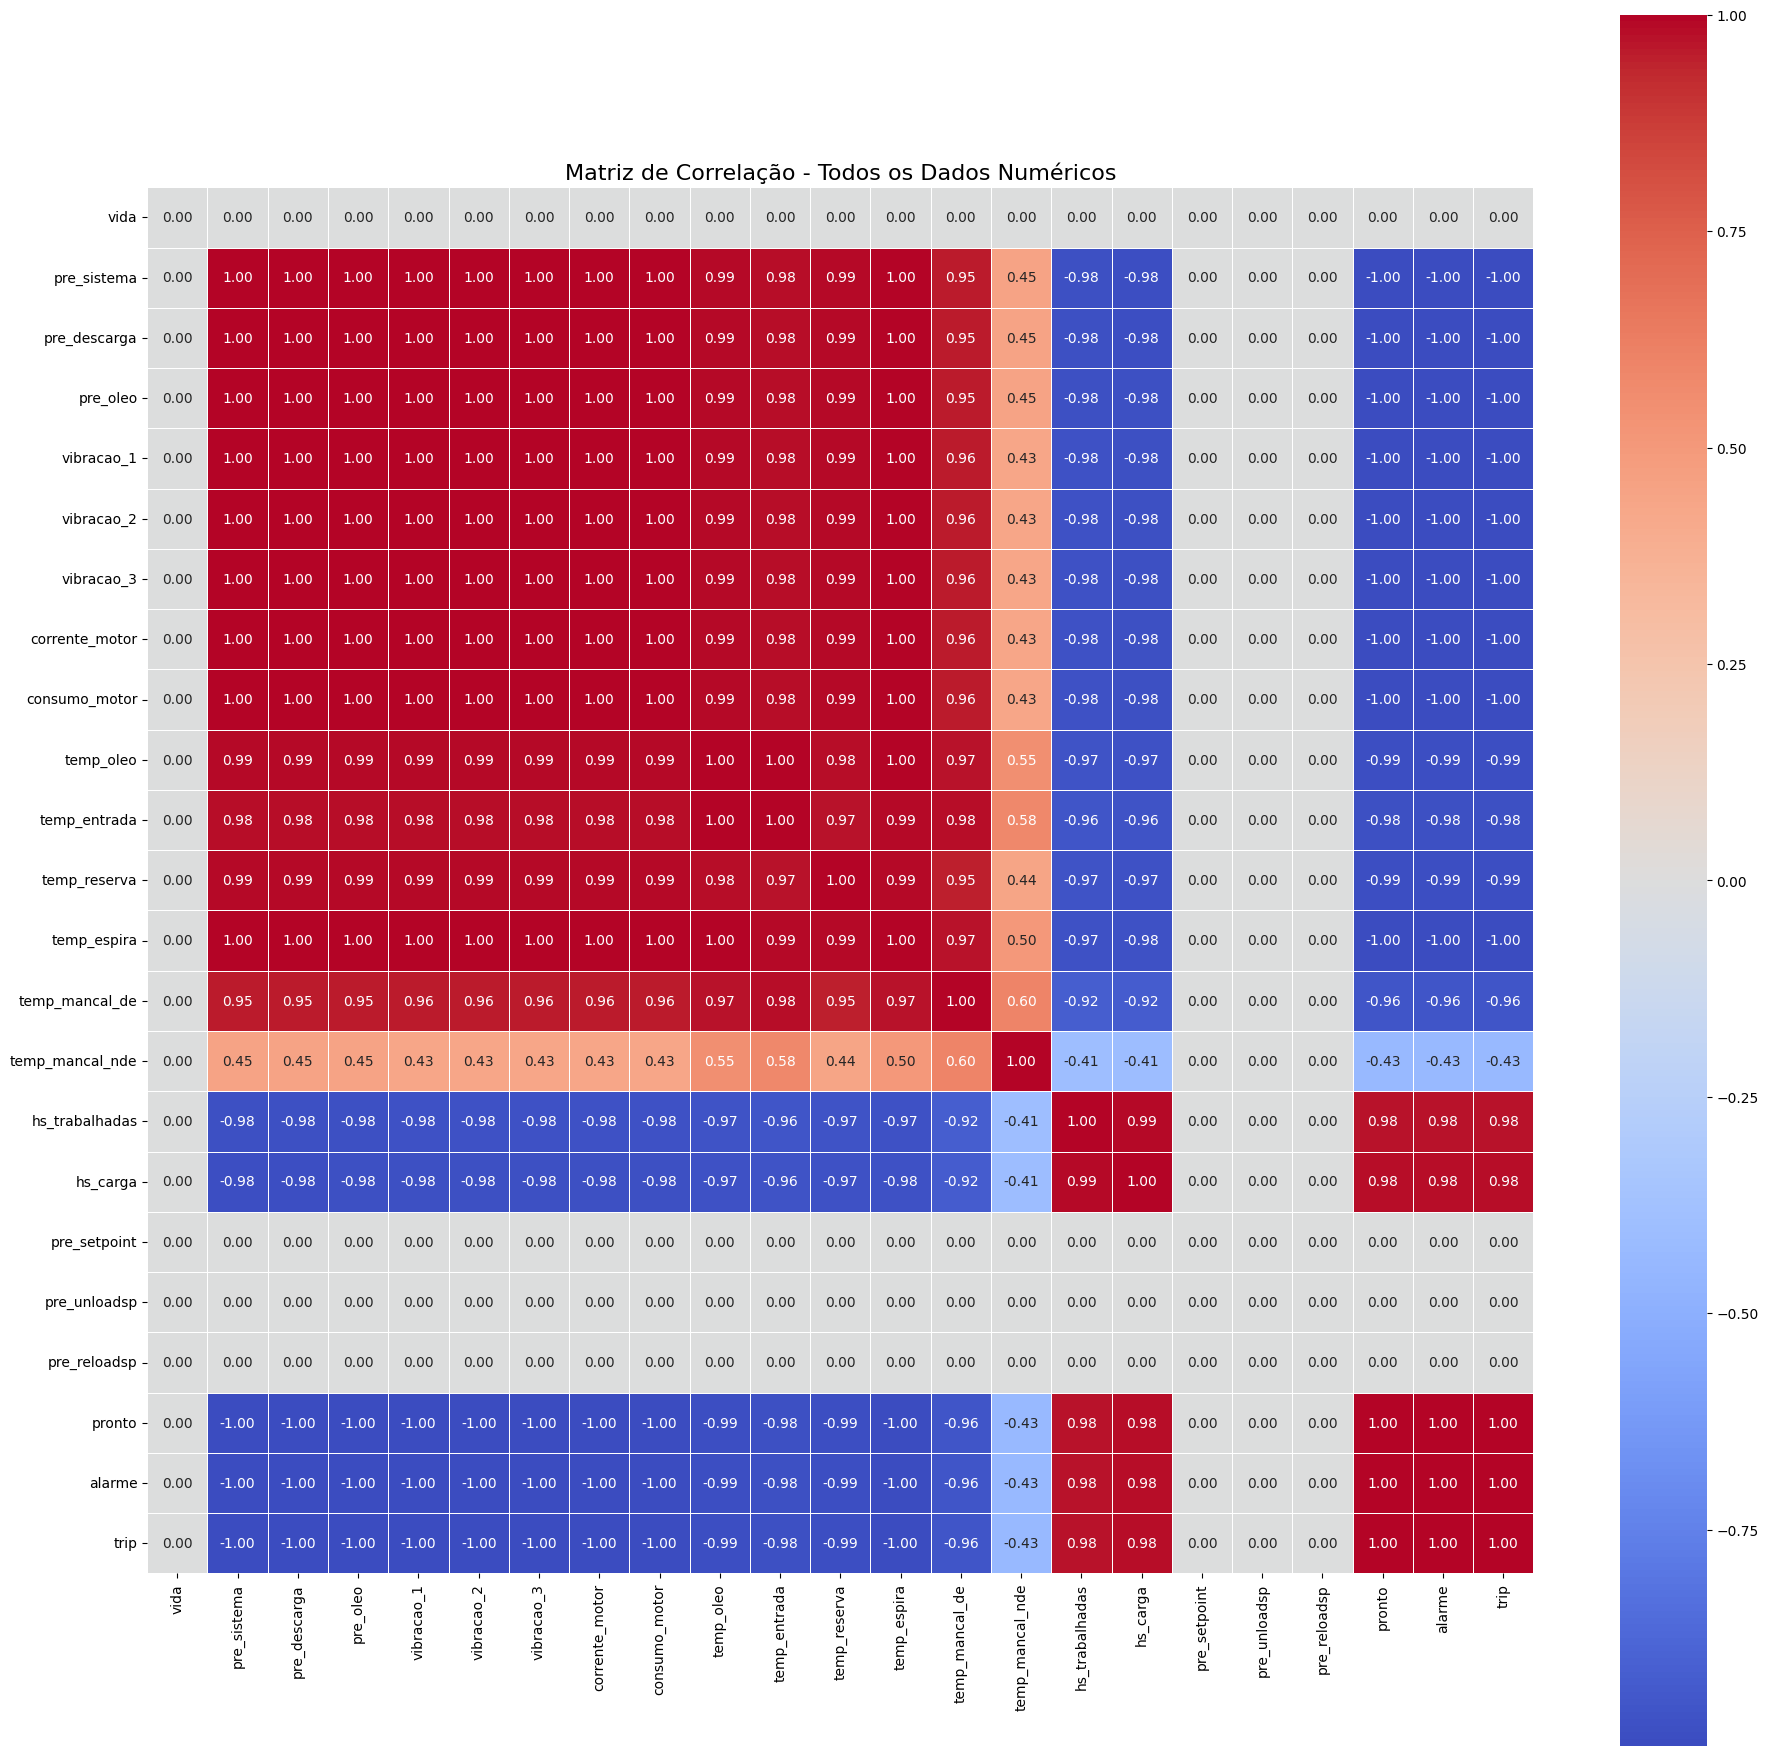

Matriz de Correlação - Todos os Dados Numéricos:
                 vida  pre_sistema  pre_descarga  pre_oleo  vibracao_1  \
vida              0.0     0.000000      0.000000  0.000000    0.000000   
pre_sistema       0.0     1.000000      1.000000  0.999978    0.999637   
pre_descarga      0.0     1.000000      1.000000  0.999978    0.999636   
pre_oleo          0.0     0.999978      0.999978  1.000000    0.999708   
vibracao_1        0.0     0.999637      0.999636  0.999708    1.000000   
vibracao_2        0.0     0.999687      0.999686  0.999725    0.999815   
vibracao_3        0.0     0.999959      0.999958  0.999972    0.999709   
corrente_motor    0.0     0.999980      0.999980  0.999986    0.999674   
consumo_motor     0.0     0.999980      0.999980  0.999986    0.999674   
temp_oleo         0.0     0.988602      0.988642  0.988596    0.988927   
temp_entrada      0.0     0.979214      0.979270  0.979193    0.979958   
temp_reserva      0.0     0.991382      0.991385  0.991409    0

In [210]:
# Seleciona apenas colunas numéricas
df_numerico = df_normalizado.select_dtypes(include=['number'])

# Calcular a matriz de correlação
matriz_corr = df_numerico.corr()

matriz_corr = matriz_corr.fillna(0)

# Plotar o heatmap
plt.figure(figsize=(19, 18))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Matriz de Correlação - Todos os Dados Numéricos', fontsize=16)
plt.tight_layout()
plt.show()

# Exibir a matriz de correlação no terminal
print("Matriz de Correlação - Todos os Dados Numéricos:")
print(matriz_corr)

## Rotulando as variáveis preditivas

In [211]:
df_normalizado['falha'] = (df_normalizado['alarme'] == 1) | (df_normalizado['trip'] == 1)  # Falha é 1 se alarme ou trip é 1
df_normalizado['falha'] = df_normalizado['falha'].astype(int)  # Converte para 0 ou 1 (binário)

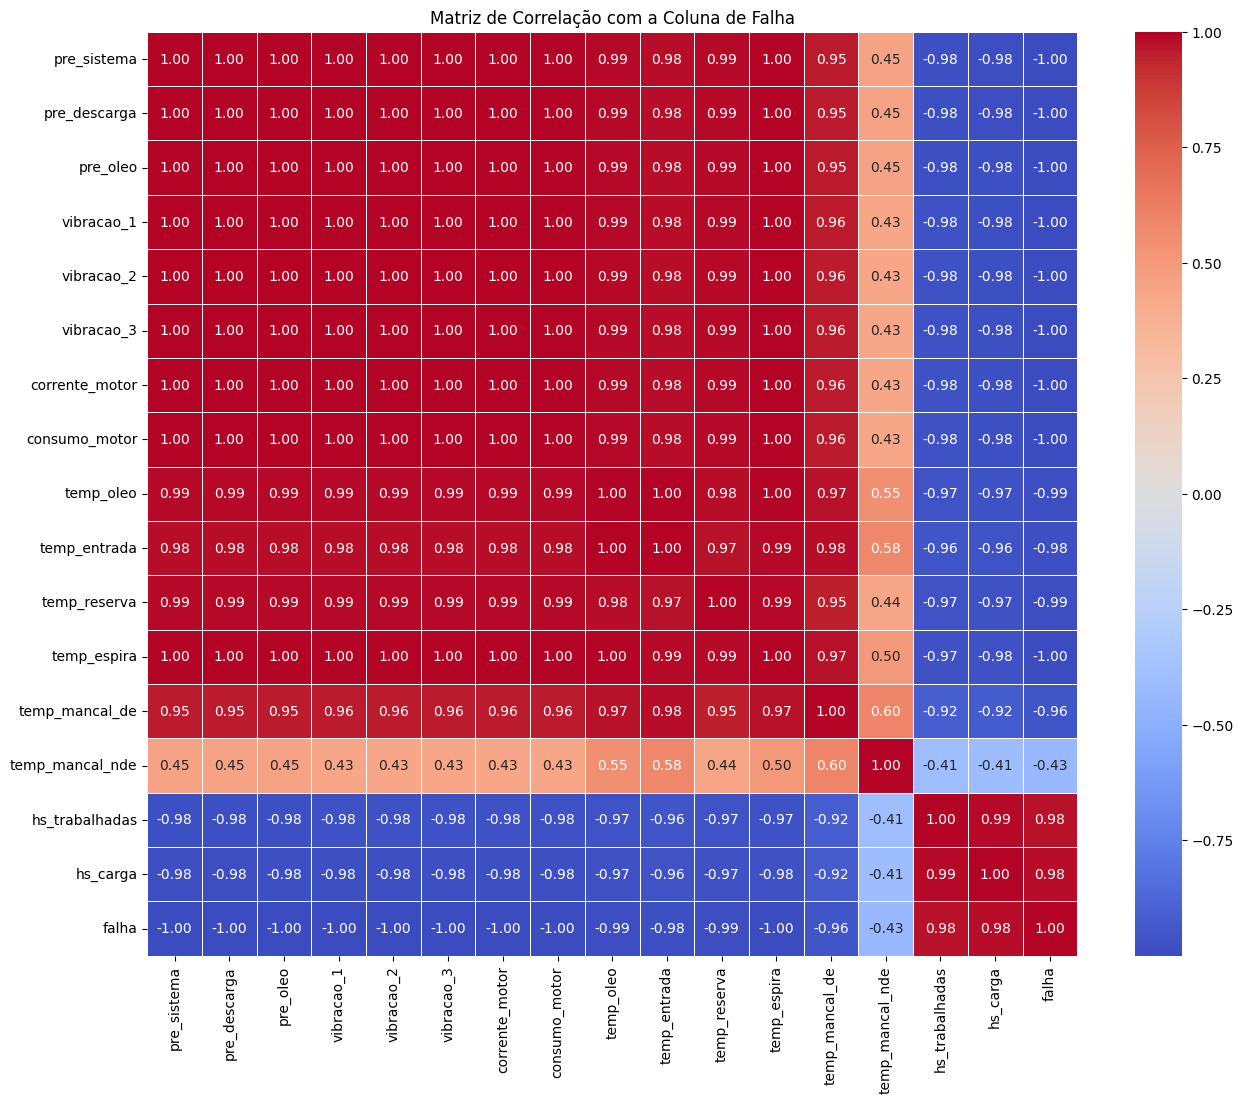

Matriz de Correlação - Todos os Dados Numéricos:
                 pre_sistema  pre_descarga  pre_oleo  vibracao_1  vibracao_2  \
pre_sistema         1.000000      1.000000  0.999978    0.999637    0.999687   
pre_descarga        1.000000      1.000000  0.999978    0.999636    0.999686   
pre_oleo            0.999978      0.999978  1.000000    0.999708    0.999725   
vibracao_1          0.999637      0.999636  0.999708    1.000000    0.999815   
vibracao_2          0.999687      0.999686  0.999725    0.999815    1.000000   
vibracao_3          0.999959      0.999958  0.999972    0.999709    0.999742   
corrente_motor      0.999980      0.999980  0.999986    0.999674    0.999652   
consumo_motor       0.999980      0.999980  0.999986    0.999674    0.999652   
temp_oleo           0.988602      0.988642  0.988596    0.988927    0.989034   
temp_entrada        0.979214      0.979270  0.979193    0.979958    0.980113   
temp_reserva        0.991382      0.991385  0.991409    0.991556    0.9

In [212]:
df_normalizado.drop(columns=['trip', 'alarme', 'pronto', 'vida', 'pre_setpoint', 'pre_unloadsp', 'pre_reloadsp', 'vida'], inplace=True)

df_numerico = df_normalizado.select_dtypes(include=['number'])

# Calcular a matriz de correlação
matriz_corr = df_numerico.corr()

matriz_corr = matriz_corr.fillna(0)

# Plotando a matriz de correlação
plt.figure(figsize=(15, 12))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação com a Coluna de Falha')
plt.show()

# Exibir a matriz de correlação no terminal
print("Matriz de Correlação - Todos os Dados Numéricos:")
print(matriz_corr)

In [213]:
# Obter a correlação da 'falha' com todas as outras variáveis
corr_falha = matriz_corr['falha'].sort_values(ascending=False)

# Exibir as variáveis mais correlacionadas com 'falha'
print("Correlação com a variável 'falha':")
print(corr_falha)


Correlação com a variável 'falha':
falha              1.000000
hs_carga           0.982704
hs_trabalhadas     0.975840
temp_mancal_nde   -0.431956
temp_mancal_de    -0.955776
temp_entrada      -0.980372
temp_oleo         -0.989285
temp_reserva      -0.991883
temp_espira       -0.995989
vibracao_1        -0.999647
vibracao_2        -0.999647
vibracao_3        -0.999977
pre_descarga      -0.999984
pre_sistema       -0.999984
pre_oleo          -0.999992
consumo_motor     -0.999995
corrente_motor    -0.999995
Name: falha, dtype: float64
